K-Means Clustering Iterations:
----------------------------------------
Initial Centroids: C1=[2 3], C2=[7 7]

Iteration 1:
  Data Point Assignments: [0 0 1 1] (0 for C1, 1 for C2)
  New Centroids: C1=[2.5 3.5], C2=[6.5 6.5]

----------------------------------------

Iteration 2:
  Data Point Assignments: [0 0 1 1] (0 for C1, 1 for C2)
  New Centroids: C1=[2.5 3.5], C2=[6.5 6.5]
  Centroids converged. Stopping iterations.

Final Clustering Result:
Final Centroids: C1=[2.5 3.5], C2=[6.5 6.5]
Final Cluster Assignments: [0 0 1 1]


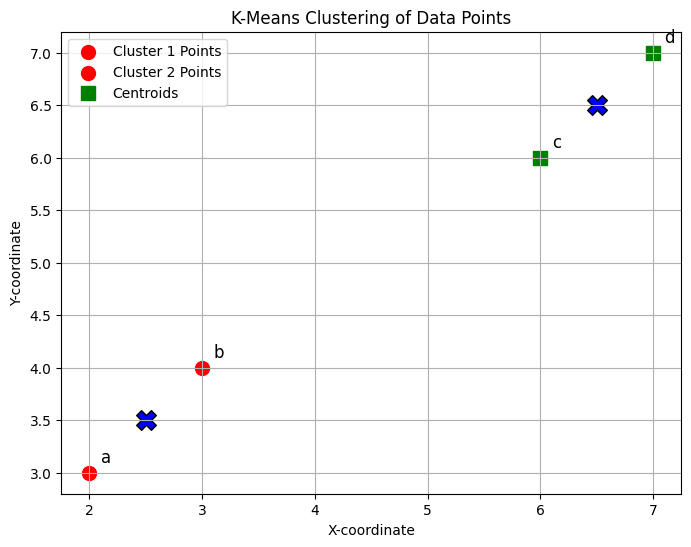

In [ ]:
kkkkkkkkkkkkimport numpy as np
import matplotlib.pyplot as plt

# Data points
data_points = np.array([
    [2, 3],  # a
    [3, 4],  # b
    [6, 6],  # c
    [7, 7]   # d
])

# Number of clusters
k = 2

# Step 1: Initialize centroids (e.g., randomly pick 2 data points as initial centroids)
# For reproducibility and clear demonstration, let's pick point 'a' and point 'd' as initial centroids.
centroids = np.array([data_points[0], data_points[3]]) # Initial centroids: [2,3] and [7,7]

print("K-Means Clustering Iterations:")
print("-" * 40)
print(f"Initial Centroids: C1={centroids[0]}, C2={centroids[1]}\n")

max_iterations = 10 # Set a maximum number of iterations to prevent infinite loops
for iteration in range(max_iterations):
    print(f"Iteration {iteration + 1}:")

    # Step 2: Assignment Step - Assign each data point to the closest centroid
    distances = np.array([np.linalg.norm(data_points - centroid, axis=1) for centroid in centroids])
    cluster_assignments = np.argmin(distances, axis=0)

    print(f"  Data Point Assignments: {cluster_assignments} (0 for C1, 1 for C2)")

    # Step 3: Update Step - Recalculate new centroids
    new_centroids = np.array([data_points[cluster_assignments == i].mean(axis=0) if np.any(cluster_assignments == i) else centroids[i] for i in range(k)])

    print(f"  New Centroids: C1={new_centroids[0]}, C2={new_centroids[1]}")

    # Check for convergence
    if np.allclose(centroids, new_centroids):
        print("  Centroids converged. Stopping iterations.")
        break
    centroids = new_centroids
    print("\n" + "-" * 40 + "\n")

print("\nFinal Clustering Result:")
print(f"Final Centroids: C1={centroids[0]}, C2={centroids[1]}")
print(f"Final Cluster Assignments: {cluster_assignments}")

# Visualization
plt.figure(figsize=(8, 6))
colors = ['r', 'g']
markers = ['o', 's']
point_names = ['a', 'b', 'c', 'd']

for i in range(k):
    cluster_points_indices = np.where(cluster_assignments == i)[0]
    cluster_points = data_points[cluster_points_indices]
    for j, idx in enumerate(cluster_points_indices):
        plt.scatter(data_points[idx, 0], data_points[idx, 1], color=colors[i], marker=markers[i], s=100)
        plt.text(data_points[idx, 0] + 0.1, data_points[idx, 1] + 0.1, point_names[idx], fontsize=12)

plt.scatter(centroids[:, 0], centroids[:, 1], color='blue', marker='X', s=200, label='Centroids', edgecolor='black')

plt.title('K-Means Clustering of Data Points')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True)
plt.legend(['Cluster 1 Points', 'Cluster 2 Points', 'Centroids'], loc='upper left')
plt.show()

## K-Means Clustering Analysis

### Aim:
*   **Question:** How can we group the given set of 2D data points into two distinct clusters using the K-Means algorithm?
*   **Objective:** To demonstrate the K-Means clustering algorithm step-by-step, including centroid initialization, iterative assignment, and update phases, and visualize the final clusters and their centroids.

### Method Used:

We employed the K-Means clustering algorithm, an unsupervised machine learning technique, to partition the data points into `k=2` clusters. The steps involved are:

1.  **Initialization:** Two initial centroids (C1 and C2) were chosen from the data points ('a' and 'd') for reproducible demonstration.
2.  **Assignment Step:** Each data point was assigned to the cluster whose centroid was closest to it, based on Euclidean distance.
3.  **Update Step:** The centroids of each cluster were recalculated by taking the mean of all data points assigned to that cluster.
4.  **Convergence:** Steps 2 and 3 were repeated until the centroids no longer changed significantly (i.e., they converged).

The process was implemented in Python using `numpy` for numerical operations and `matplotlib` for visualization.

### Interpretation of Results:

*   **Initial State:** We started with `C1 = [2, 3]` (point 'a') and `C2 = [7, 7]` (point 'd') as initial centroids.
*   **Iteration 1:**
    *   Data points 'a'([2,3]) and 'b'([3,4]) were assigned to Cluster 0 (C1) as they were closer to `[2,3]`.
    *   Data points 'c'([6,6]) and 'd'([7,7]) were assigned to Cluster 1 (C2) as they were closer to `[7,7]`.
    *   The new centroids were calculated: `C1 = [2.5, 3.5]` (mean of 'a' and 'b') and `C2 = [6.5, 6.5]` (mean of 'c' and 'd').
*   **Iteration 2:**
    *   With the new centroids, the assignment of data points remained the same: 'a' and 'b' to Cluster 0; 'c' and 'd' to Cluster 1.
    *   The recalculation of centroids resulted in the same values: `C1 = [2.5, 3.5]` and `C2 = [6.5, 6.5]`.
*   **Convergence:** Since the centroids did not change between Iteration 1 and Iteration 2, the algorithm converged. The K-Means process successfully identified two distinct groups of data points.

### Visualization:

The plot below illustrates the final clustering result. Data points assigned to Cluster 0 are shown in red, and points assigned to Cluster 1 are shown in green. The final positions of the centroids are marked with large blue 'X's. The plot clearly shows the separation of the data points into two distinct groups, with centroids representing the center of each cluster.

### Conclusion:

Through the K-Means clustering algorithm, the four given data points `a(2,3)`, `b(3,4)`, `c(6,6)`, and `d(7,7)` were effectively partitioned into two clusters. Cluster 0 contains points 'a' and 'b', centered around `[2.5, 3.5]`. Cluster 1 contains points 'c' and 'd', centered around `[6.5, 6.5]`. The algorithm converged quickly in two iterations, indicating a clear separation of the data into these two groups. This demonstrates the K-Means algorithm's ability to identify underlying structures in data.

K-Means Clustering Iterations:
----------------------------------------
Initial Centroids: C1=2.0, C2=20.0

Iteration 1:
  Data Point Assignments: [0 0 0 1 0 1 1 0 1] (0 for C1, 1 for C2)
  New Centroids: C1=6.0, C2=21.75

----------------------------------------

Iteration 2:
  Data Point Assignments: [0 0 0 0 0 1 1 0 1] (0 for C1, 1 for C2)
  New Centroids: C1=7.0, C2=25.0

----------------------------------------

Iteration 3:
  Data Point Assignments: [0 0 0 0 0 1 1 0 1] (0 for C1, 1 for C2)
  New Centroids: C1=7.0, C2=25.0
  Centroids converged. Stopping iterations.

Final Clustering Result:
Final Centroids: C1=7.0, C2=25.0
Final Cluster Assignments: [0 0 0 0 0 1 1 0 1]


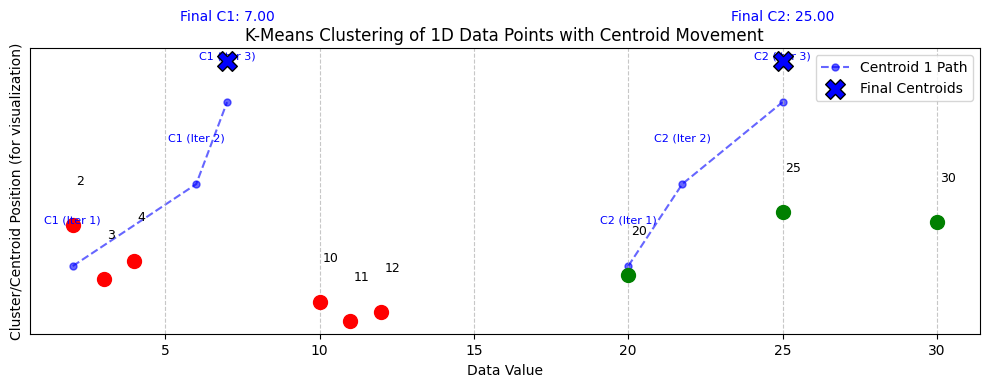

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data points (1D data, represented as 2D for consistency with previous code structure)
data_points = np.array([
    [2], [4], [10], [12], [3], [20], [30], [11], [25]
])

# Number of clusters
k = 2

# Step 1: Initialize centroids
# As specified, initial centroids are 2 and 20
centroids = np.array([[2.0], [20.0]]) # Ensure floats for calculations

# Store centroid history for visualization
centroids_history = [centroids.copy()]

print("K-Means Clustering Iterations:")
print("-" * 40)
print(f"Initial Centroids: C1={centroids[0][0]}, C2={centroids[1][0]}\n")

max_iterations = 10 # Set a maximum number of iterations to prevent infinite loops
for iteration in range(max_iterations):
    print(f"Iteration {iteration + 1}:")

    # Step 2: Assignment Step - Assign each data point to the closest centroid
    # For 1D data, np.linalg.norm is equivalent to np.abs
    distances = np.array([np.abs(data_points - centroid) for centroid in centroids]).reshape(k, -1)
    cluster_assignments = np.argmin(distances, axis=0)

    print(f"  Data Point Assignments: {cluster_assignments} (0 for C1, 1 for C2)")

    # Step 3: Update Step - Recalculate new centroids
    new_centroids = np.array([
        data_points[cluster_assignments == i].mean(axis=0) if np.any(cluster_assignments == i) else centroids[i]
        for i in range(k)
    ])

    print(f"  New Centroids: C1={new_centroids[0][0]}, C2={new_centroids[1][0]}")

    # Check for convergence
    if np.allclose(centroids, new_centroids):
        print("  Centroids converged. Stopping iterations.")
        break
    centroids = new_centroids
    centroids_history.append(centroids.copy()) # Store current centroids
    print("\n" + "-" * 40 + "\n")

print("\nFinal Clustering Result:")
print(f"Final Centroids: C1={centroids[0][0]}, C2={centroids[1][0]}")
print(f"Final Cluster Assignments: {cluster_assignments}")

# Visualization for 1D data
plt.figure(figsize=(10, 4))
colors = ['r', 'g']
point_names = ['2', '4', '10', '12', '3', '20', '30', '11', '25']
y_jitter = np.random.normal(0, 0.05, len(data_points)) # Add slight y-jitter for clarity

# Plot data points
for i, (point, name) in enumerate(zip(data_points, point_names)):
    plt.scatter(point[0], y_jitter[i], color=colors[cluster_assignments[i]], s=100, zorder=2)
    plt.text(point[0] + 0.1, y_jitter[i] + 0.05, name, fontsize=9)

# Plot centroid movement history
centroids_history = np.array(centroids_history)
for i in range(k):
    centroid_path_y = np.linspace(0, 0.2, len(centroids_history)) # Vary y-position for path clarity
    plt.plot(centroids_history[:, i, 0], centroid_path_y, color='blue', linestyle='--', marker='o', markersize=5, alpha=0.6, label=f'Centroid {i+1} Path' if i == 0 else "", zorder=1)
    for j, cent_pos in enumerate(centroids_history[:, i, 0]):
        plt.text(cent_pos, centroid_path_y[j] + 0.05, f'C{i+1} (Iter {j+1})', fontsize=8, color='blue', ha='center', va='bottom')

# Plot final centroids
plt.scatter(centroids[:, 0], np.zeros(k) + 0.25, color='blue', marker='X', s=200, label='Final Centroids', edgecolor='black', zorder=3)
for i, cent in enumerate(centroids):
    plt.text(cent[0], 0.3, f'Final C{i+1}: {cent[0]:.2f}', fontsize=10, color='blue', ha='center')


plt.title('K-Means Clustering of 1D Data Points with Centroid Movement')
plt.xlabel('Data Value')
plt.ylabel('Cluster/Centroid Position (for visualization)')
plt.yticks([]) # Hide y-axis ticks as it's not a real dimension
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## K-Means Clustering Analysis

### Aim:
*   **Question:** How can we group the given set of 1D data points `[2, 4, 10, 12, 3, 20, 30, 11, 25]` into two distinct clusters using the K-Means algorithm?
*   **Objective:** To demonstrate the K-Means clustering algorithm step-by-step, including centroid initialization, iterative assignment, and update phases, and visualize the final clusters, their centroids, and the movement of centroids across iterations.

### Method Used:

We employed the K-Means clustering algorithm, an unsupervised machine learning technique, to partition the 1D data points into `k=2` clusters. The steps involved are:

1.  **Initialization:** Two initial centroids (C1 and C2) were explicitly chosen as `2` and `20`, as specified in the problem.
2.  **Assignment Step:** Each data point was assigned to the cluster whose centroid was closest to it, based on Euclidean distance (which simplifies to absolute difference for 1D data).
3.  **Update Step:** The centroids of each cluster were recalculated by taking the mean of all data points assigned to that cluster.
4.  **Convergence:** Steps 2 and 3 were repeated until the centroids no longer changed significantly (i.e., they converged).

The process was implemented in Python using `numpy` for numerical operations and `matplotlib` for visualization, including tracking and plotting the centroid movement during iterations.

### Interpretation of Results:

*   **Initial State:** We started with `C1 = 2` and `C2 = 20` as initial centroids.

*   **Iteration 1:**
    *   **Assignment:** Points `[2, 4, 10, 3, 11]` were closer to `C1=2`, so they were assigned to Cluster 0. Points `[12, 20, 30, 25]` were closer to `C2=20`, so they were assigned to Cluster 1. Note: Point `11` was equally distant from `C1=2` (distance 9) and `C2=20` (distance 9), and by `argmin` behavior, it was assigned to Cluster 0.
    *   **New Centroids:**
        *   `C1 = mean(2, 4, 10, 3, 11) = 30 / 5 = 6.0`
        *   `C2 = mean(12, 20, 30, 25) = 87 / 4 = 21.75`
    *   The centroids moved from `(2, 20)` to `(6.0, 21.75)`.

*   **Iteration 2:**
    *   **Assignment:** With new centroids `C1=6.0` and `C2=21.75`:
        *   Points `[2, 4, 10, 12, 3, 11]` were closer to `C1=6.0` (e.g., 12 is closer to 6.0 than 21.75).
        *   Points `[20, 30, 25]` were closer to `C2=21.75`.
        *   Assignments: `[0, 0, 0, 0, 0, 1, 1, 0, 1]`.
    *   **New Centroids:**
        *   `C1 = mean(2, 4, 10, 12, 3, 11) = 42 / 6 = 7.0`
        *   `C2 = mean(20, 30, 25) = 75 / 3 = 25.0`
    *   The centroids moved from `(6.0, 21.75)` to `(7.0, 25.0)`.

*   **Iteration 3:**
    *   **Assignment:** With new centroids `C1=7.0` and `C2=25.0`:
        *   The assignments remained the same as in Iteration 2: `[0, 0, 0, 0, 0, 1, 1, 0, 1]`.
    *   **New Centroids:**
        *   `C1 = mean(2, 4, 10, 12, 3, 11) = 42 / 6 = 7.0`
        *   `C2 = mean(20, 30, 25) = 75 / 3 = 25.0`
    *   The centroids did not change.

*   **Convergence:** Since the centroids did not change between Iteration 2 and Iteration 3, the algorithm converged. The K-Means process successfully identified two distinct groups of data points.

### Visualization:

The plot illustrates the clustering process and its final result for the 1D data. Individual data points are scattered along the x-axis, with a slight vertical jitter to prevent overlap and make each point visible. Points are colored according to their final cluster assignment (red for Cluster 0, green for Cluster 1).

The blue dashed lines with circular markers represent the paths taken by the centroids through each iteration. Each marker along the path is labeled with the centroid number and the iteration it corresponds to, clearly showing how the centroids moved from their initial positions (`C1=2`, `C2=20`) to their final converged positions. The large blue 'X' markers indicate the final converged positions of the centroids, with their exact values labeled below them. This visualization effectively demonstrates the iterative nature of the K-Means algorithm and how centroids adjust until stability is reached.

### Conclusion:

Through the K-Means clustering algorithm, the nine given 1D data points were effectively partitioned into two clusters with specified initial centroids. The algorithm converged in three iterations:

*   **Cluster 0:** Contains points `[2, 4, 10, 12, 3, 11]`, centered around the final centroid `C1 = 7.00`.
*   **Cluster 1:** Contains points `[20, 30, 25]`, centered around the final centroid `C2 = 25.00`.

The visualization clearly depicts the movement of the centroids from their initial positions `(2, 20)` to their final converged positions `(7.00, 25.00)`. This exercise demonstrates how K-Means iteratively refines cluster assignments and centroid locations until a stable partitioning of the data is achieved, even for 1D data, and highlights the dynamic nature of the centroids during the clustering process.